# Pneumonia Detection with VGG16 Transfer Learning

**Dataset:** Chest X-Ray Images (Pneumonia) — [Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)  
**Architecture:** VGG16 backbone (frozen) + custom classification head  
**Framework:** TensorFlow / Keras  


## 1. Imports

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.20.0
GPU available: True


## 2. Configuration

In [16]:
CONFIG = {
    "img_size"        : (224, 224),
    "batch_size"      : 32,
    "learning_rate"   : 5e-5,
    "epochs"          : 30,
    "dropout_rate"    : 0.6,
    "dense_units"     : 1024,
    "es_patience"     : 5,
    "lr_patience"     : 3,
    "base_dir"        : "chest_xray_data/chest_xray",
    "class_names"     : ["Normal", "Pneumonia"],
    "model_save_path" : "pneumonia_vgg16.keras",
}

## 3. Dataset Download

In [17]:
!pip install -q kaggle --upgrade

from google.colab import files
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data
!ls chest_xray_data/chest_xray

Saving kaggle (1).json to kaggle (1) (1).json
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
replace chest_xray_data/chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
a
A
a
A
AL
ALL
Y
chest_xray  __MACOSX  test  train  val


## 4. Data Paths

In [18]:
train_dir = os.path.join(CONFIG["base_dir"], "train")
val_dir   = os.path.join(CONFIG["base_dir"], "val")
test_dir  = os.path.join(CONFIG["base_dir"], "test")

for split, path in [("Train", train_dir), ("Val", val_dir), ("Test", test_dir)]:
    n = sum(len(files) for _, _, files in os.walk(path))
    print(f"{split:6s}: {n:5d} images  →  {path}")

Train :  5216 images  →  chest_xray_data/chest_xray/train
Val   :    16 images  →  chest_xray_data/chest_xray/val
Test  :   624 images  →  chest_xray_data/chest_xray/test


## 5. Data Generators

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode="nearest",
    brightness_range=[0.8, 1.2],
)
eval_datagen = ImageDataGenerator(rescale=1./255)


def make_generator(datagen, directory, shuffle):
    return datagen.flow_from_directory(
        directory,
        target_size=CONFIG["img_size"],
        batch_size=CONFIG["batch_size"],
        class_mode="categorical",
        shuffle=shuffle,
    )


train_generator = make_generator(train_datagen, train_dir, shuffle=True)
val_generator   = make_generator(eval_datagen,  val_dir,   shuffle=False)
test_generator  = make_generator(eval_datagen,  test_dir,  shuffle=False)

print(f"\nTrain images : {train_generator.samples}")
print(f"Val   images : {val_generator.samples}")
print(f"Test  images : {test_generator.samples}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Train images : 5216
Val   images : 16
Test  images : 624


## 6. Exploratory Data Analysis

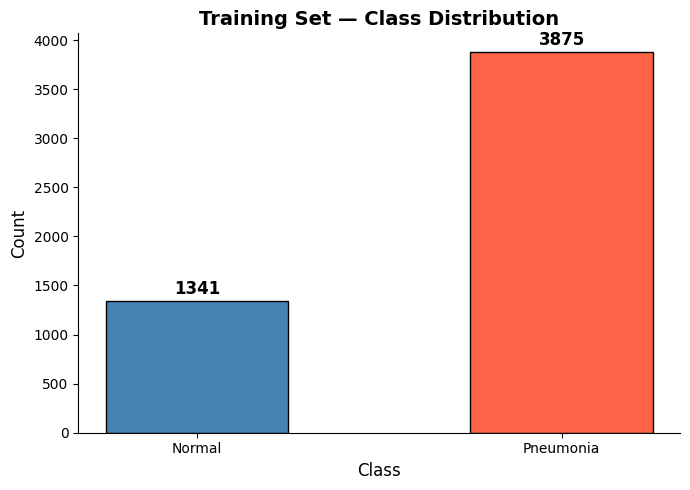

In [20]:
unique, counts = np.unique(train_generator.classes, return_counts=True)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    CONFIG["class_names"], counts,
    color=["steelblue", "tomato"], edgecolor="black", width=0.5
)
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30, str(count),
        ha="center", va="bottom", fontweight="bold", fontsize=12
    )
ax.set_title("Training Set — Class Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

## 7. Class Weights

In [21]:
raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes,
)
class_weight_dict = {i: float(w * 1.2) for i, w in enumerate(raw_weights)}

for cls_id, weight in class_weight_dict.items():
    print(f"  {CONFIG['class_names'][cls_id]:10s}: {weight:.4f}")

  Normal    : 2.3338
  Pneumonia : 0.8076


## 8. Model Architecture

In [22]:
def build_model(
    input_shape=(224, 224, 3),
    num_classes=2,
    dense_units=1024,
    dropout_rate=0.6,
    learning_rate=5e-5,
):
    base = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False

    x   = Flatten()(base.output)
    x   = Dense(dense_units, activation="relu")(x)
    x   = Dropout(dropout_rate)(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base.input, outputs=out, name="PneumoniaVGG16")
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_model(
    dense_units=CONFIG["dense_units"],
    dropout_rate=CONFIG["dropout_rate"],
    learning_rate=CONFIG["learning_rate"],
)
model.summary()

Model: "PneumoniaVGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │    25,691,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,407,874 (154.14 MB)

 Trainable params: 25,693,186 (98.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 9. Training

In [23]:
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=CONFIG["es_patience"],
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=CONFIG["lr_patience"],
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        CONFIG["model_save_path"],
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=max(1, val_generator.samples // val_generator.batch_size),
    epochs=CONFIG["epochs"],
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.7690 - loss: 0.5920
Epoch 1: val_accuracy improved from None to 0.81250, saving model to pneumonia_vgg16.keras

Epoch 1: finished saving model to pneumonia_vgg16.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 153s 884ms/step - accuracy: 0.8236 - loss: 0.4636 - val_accuracy: 0.8125 - val_loss: 0.4574 - learning_rate: 5.0000e-05
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.8723 - loss: 0.3543
Epoch 2: val_accuracy did not improve from 0.81250
163/163 ━━━━━━━━━━━━━━━━━━━━ 176s 754ms/step - accuracy: 0.8779 - loss: 0.3427 - val_accuracy: 0.8125 - val_loss: 0.3062 - learning_rate: 5.0000e-05
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.8714 - loss: 0.3477
Epoch 3: val_accuracy did not improve from 0.81250
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 748ms/step - accuracy: 0.8777 - loss: 0.3404 - val_accuracy: 0.8125 - val_loss: 0.3901 - learning_rate: 5.0000e-05
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━

## 10. Training Curves

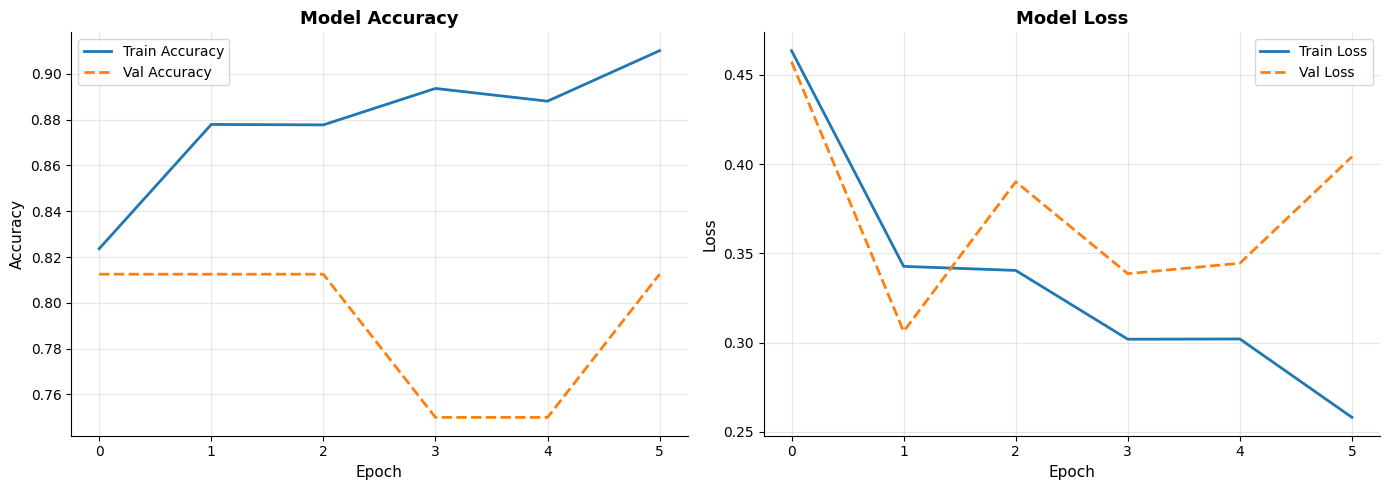

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    ax.plot(history.history[metric],            label=f"Train {title}", linewidth=2)
    ax.plot(history.history[f"val_{metric}"],   label=f"Val {title}",   linewidth=2, linestyle="--")
    ax.set_title(f"Model {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

## 11. Evaluation

In [25]:
CLASS_NAMES = CONFIG["class_names"]

test_generator.reset()
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

test_generator.reset()
predictions  = model.predict(test_generator, verbose=1)
pred_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

print("\n" + "=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(true_classes, pred_classes, target_names=CLASS_NAMES))

auc = roc_auc_score(true_classes, predictions[:, 1])
print(f"ROC-AUC Score : {auc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 578ms/step - accuracy: 0.8606 - loss: 0.3332

Test Accuracy : 86.06%
Test Loss     : 0.3332
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 334ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.82      0.81      0.81       234
   Pneumonia       0.89      0.89      0.89       390

    accuracy                           0.86       624
   macro avg       0.85      0.85      0.85       624
weighted avg       0.86      0.86      0.86       624

ROC-AUC Score : 0.9265


## 12. Confusion Matrix

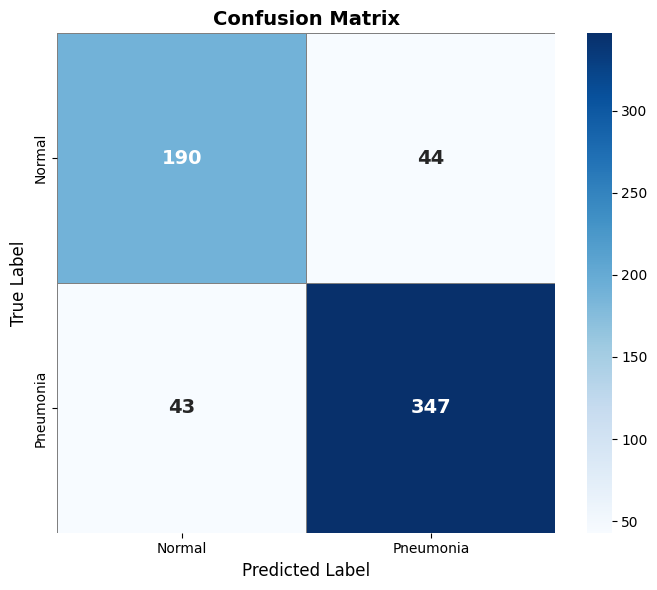

In [26]:
cm = confusion_matrix(true_classes, pred_classes)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor="gray",
    annot_kws={"size": 14, "weight": "bold"},
    ax=ax,
)
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 13. Sample Predictions

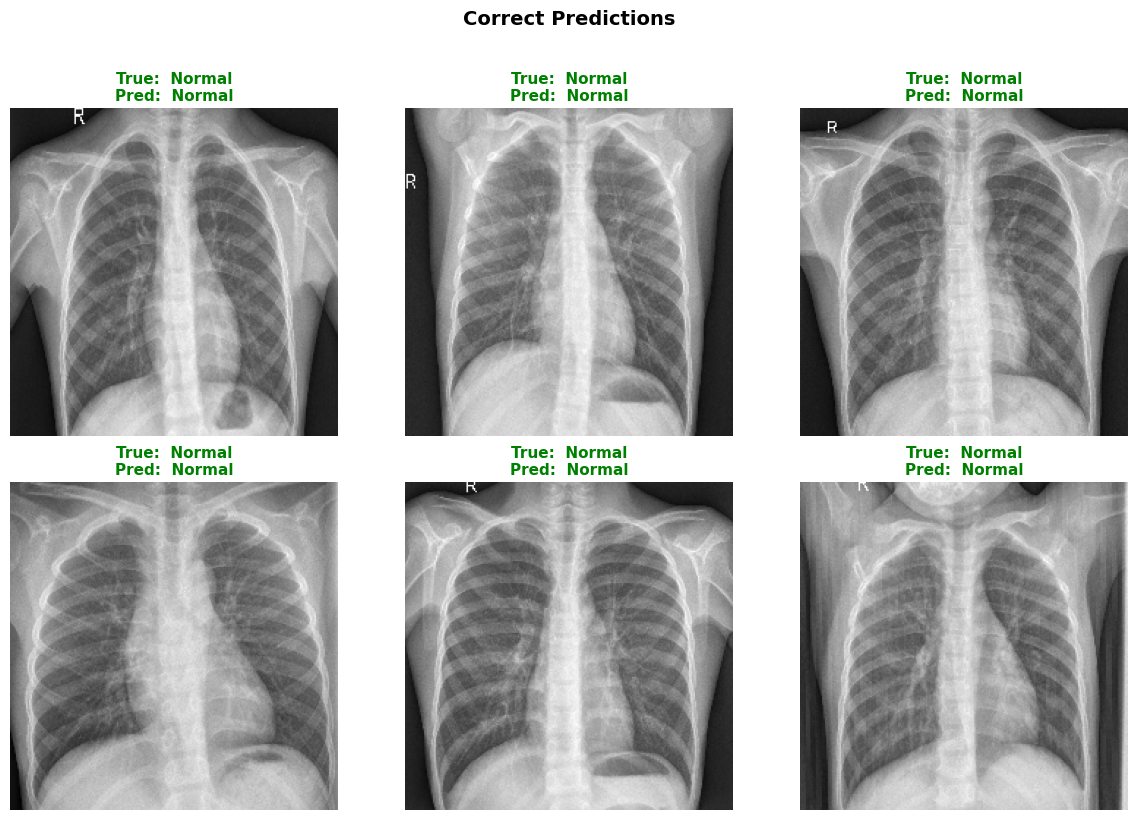

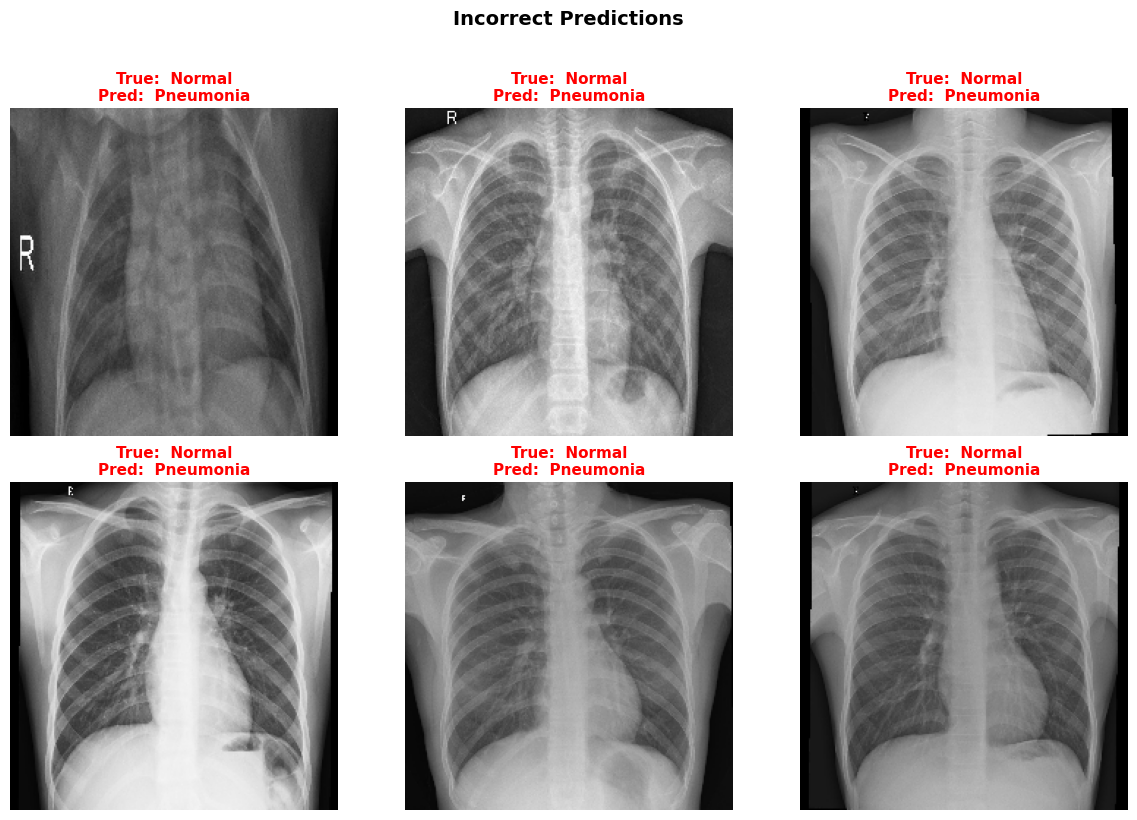

In [27]:
test_generator.reset()
all_images = np.concatenate([test_generator[i][0] for i in range(len(test_generator))])
all_labels = np.concatenate([test_generator[i][1] for i in range(len(test_generator))])
all_labels = np.argmax(all_labels, axis=1)


def plot_predictions(images, true_labels, pred_labels, class_names, indices, title):
    n = min(len(indices), 6)
    if n == 0:
        return
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).ravel()
    for ax, idx in zip(axes[:n], indices[:n]):
        ax.imshow(images[idx])
        color = "green" if pred_labels[idx] == true_labels[idx] else "red"
        ax.set_title(
            f"True:  {class_names[true_labels[idx]]}\nPred:  {class_names[pred_labels[idx]]}",
            color=color, fontsize=11, fontweight="bold",
        )
        ax.axis("off")
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()


correct_idx   = np.where(pred_classes == true_classes)[0]
incorrect_idx = np.where(pred_classes != true_classes)[0]

plot_predictions(all_images, all_labels, pred_classes, CLASS_NAMES,
                 correct_idx,   "Correct Predictions")
plot_predictions(all_images, all_labels, pred_classes, CLASS_NAMES,
                 incorrect_idx, "Incorrect Predictions")

## 14. Save Model

In [28]:
model.save(CONFIG["model_save_path"])
print(f"Model saved → {CONFIG['model_save_path']}")

Model saved → pneumonia_vgg16.keras
